Loaded Wang & Merida (horizontal): 15 Tv points, 15 BOG points.
Eval 01: U=0.00233400, eta_w=0.50000, J=2150.775071
Eval 02: U=0.00233401, eta_w=0.50000, J=2150.792227
Eval 03: U=0.00233400, eta_w=0.50000, J=2150.774892
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.0754e+03                                    2.93e+03    
Eval 04: U=0.00169349, eta_w=0.67174, J=443.006248
Eval 05: U=0.00169351, eta_w=0.67174, J=443.011190
Eval 06: U=0.00169349, eta_w=0.67174, J=443.006191
       1              2         2.2150e+02      8.54e+02       1.72e-01       6.10e+02    
Eval 07: U=0.00127577, eta_w=0.78448, J=86.903157
Eval 08: U=0.00127578, eta_w=0.78448, J=86.904677
Eval 09: U=0.00127577, eta_w=0.78448, J=86.903138
       2              3         4.3452e+01      1.78e+02       1.13e-01       1.30e+02    
Eval 10: U=0.00102890, eta_w=0.85363, J=15.765073
Eval 11: U=0.00102891, eta_w=0.85363, J=15.765511
Eval 12: U=0.

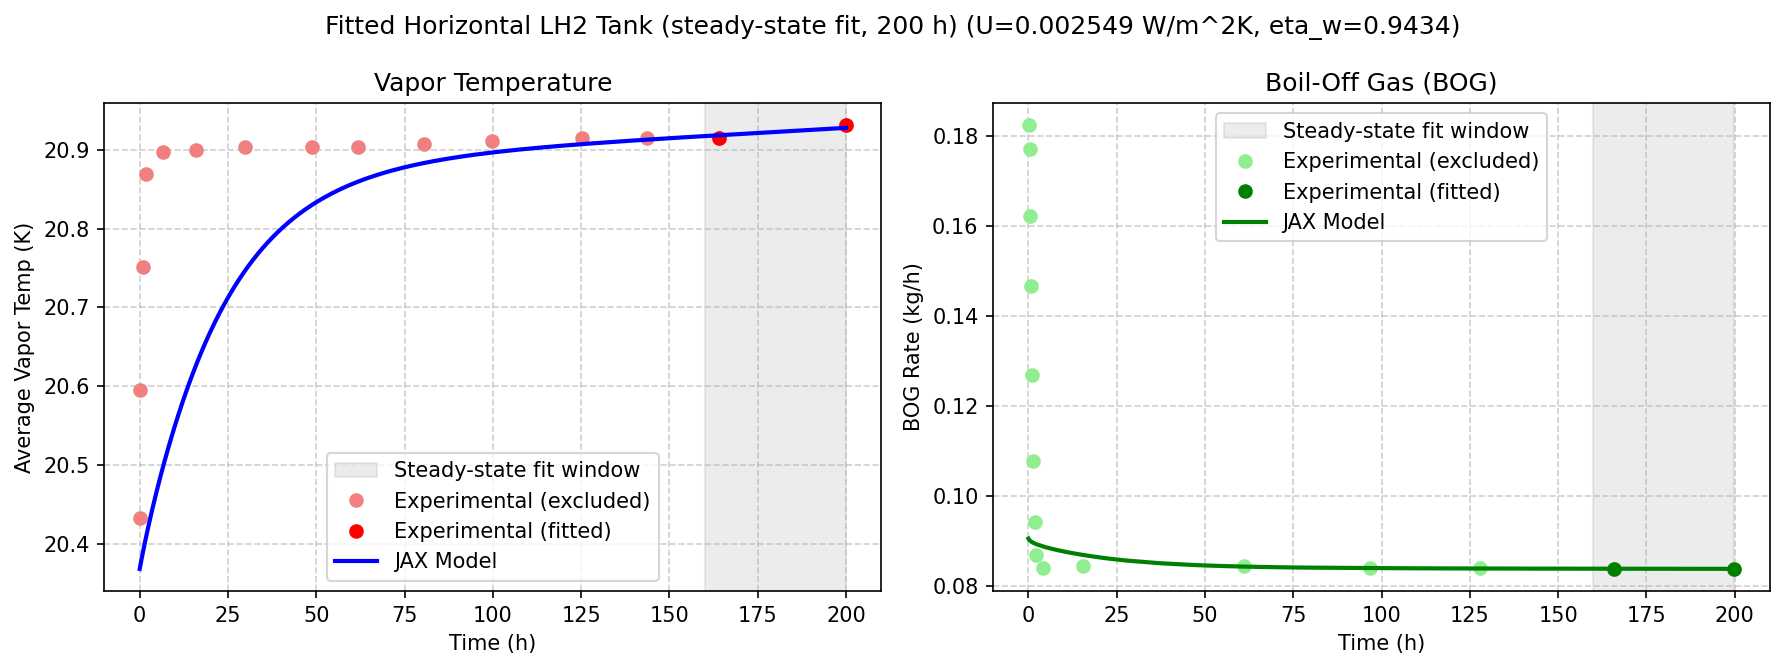

In [ ]:
import numpy as np
from cryoevap.storage_tanks import Tank
from cryoevap.cryogens import Cryogen
from cryoevap.optimize import ParameterFittingJAX

# 1. Setup Tank geometry & cryogen
P = 101300.0
h2 = Cryogen(name='hydrogen')
h2.set_coolprops(P)

tank = Tank(
    d_i=1.676,
    d_o=1.676,
    V=4.89,
    vapour_geometry='horizontal',   # or 'cylindrical'
    liquid_geometry='horizontal',
    LF=0.30,
    L=2.217,
    head_type='flat'
)
tank.cryogen = h2
tank.set_HeatTransProps(U_L=0.002, U_V=0.002, T_air=288.15, eta_w=0.5)

# 2. Instantiate JAX Parameter Fitter
fitter = ParameterFittingJAX(tank)

# 3. Load experimental data (e.g. Wang & Merida) - full 200 h dataset
data_path = '/home/felipe/CryoEvap/'


fitter.from_wang_merida(data_path + 'data/Data_wang_merida.xlsx', case='horizontal', t_max_h=200.0)

# 4. Fit parameters [U, eta_w] against the STEADY-STATE Tv_avg / BOG values only.
#    Our reduced-order model's transient response is expected to differ from
#    Wang & Merida's (different model), so we only fit the asymptotic
#    (steady-state) values reached over the last `steady_state_frac` of the
#    200 h time window, instead of matching the full transient point-by-point.
theta0 = np.array([0.002334, 0.50])
res = fitter.fit_least_squares(
    theta0,
    bounds=([0.001, 0.10], [0.1, 0.99]),
    steady_state=True,
    steady_state_frac=0.2,
    verbose=2
)

print("Optimal parameters:", res['x'])

# 5. Plot model comparison against experimental points (steady-state fit window shaded)
fig, axes = fitter.plot_fit(
    res['x'],
    title="Fitted Horizontal LH2 Tank (steady-state fit, 200 h)",
    steady_state=True,
    steady_state_frac=0.2
)